# Run this first !

In [4]:
# project setup — run first, do not edit except NAME
NAME = "rachel" # <<< your name

import sys, subprocess, pathlib
IN_COLAB = "google.colab" in sys.modules
REPO = "boe-financial-analysis"

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
    if not pathlib.Path(f"/content/{REPO}").exists():
        subprocess.run(["git", "clone", "-q",
                        f"https://github.com/maybebool/{REPO}.git",
                        f"/content/{REPO}"], check=True)
    ROOT = pathlib.Path(f"/content/{REPO}")
    DATA = pathlib.Path("/content/drive/MyDrive/boe-data")
else:
    ROOT = pathlib.Path.cwd()
    while not (ROOT / "requirements.txt").exists() and ROOT != ROOT.parent:
        ROOT = ROOT.parent
    DATA = ROOT / "data"

sys.path.insert(0, str(ROOT))
subprocess.run(["git", "-C", str(ROOT), "fetch", "-q", "origin"], check=False)
subprocess.run(["git", "-C", str(ROOT), "merge", "-q", "origin/main", "-m", "sync"],
               check=False)
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r",
                str(ROOT / "requirements.txt")], check=True)

from notebooks.env_cell import verify, check_python
check_python()
try:
    verify(ROOT)
except RuntimeError as e:
    print(e)
    print("\n Runtime -> Restart session, then run this cell again.")
    raise

import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from src import loading

print(f"ok  python {sys.version.split()[0]}  pandas {pd.__version__}  data {DATA}")

ok  python 3.12.13  pandas 2.2.3  data /Users/rdrobinson/Cambridge/boe-financial-analysis/data


In [5]:
print(loading.exports(DATA))
print(loading.files(DATA))

utt = loading.load(DATA, "all_utterances.csv", "2026-09-13")
sent = loading.load(DATA, "all_sentences.csv", "2026-09-13")
met = loading.load(DATA, "all_metrics.csv", "2026-09-13")

print(utt.shape, sent.shape, met.shape)
sent.head()

['2026-09-13']
['all_metrics.csv', 'all_sentences.csv', 'all_utterances.csv']
loaded all_utterances.csv  1201 rows
loaded all_sentences.csv  9519 rows
loaded all_metrics.csv  510 rows
(1201, 11) (9519, 12) (510, 6)


,bank,quarter,call_type,call_date,position_in_call,section,speaker_role,speaker_name,speaker_institution,sentence_id,sentence_number,sentence
0,JPM,2023-Q1,earnings,2023-04-14,1,prepared,operator,Operator,NaN,9789,1,"Good morning, ladies and gentlemen."
1,JPM,2023-Q1,earnings,2023-04-14,1,prepared,operator,Operator,NaN,9790,2,Welcome to JPMorgan Chase’s First Quarter 2023...
2,JPM,2023-Q1,earnings,2023-04-14,1,prepared,operator,Operator,NaN,9791,3,This call is being recorded.
3,JPM,2023-Q1,earnings,2023-04-14,1,prepared,operator,Operator,NaN,9792,4,Your line will be muted for the duration of th...
4,JPM,2023-Q1,earnings,2023-04-14,1,prepared,operator,Operator,NaN,9793,5,We will now go live to the presentation.


In [6]:
data=sent.copy()

# Data distributions

## Missing values
All OK apart from Speaker Institution (probably not needed anyway)

In [ ]:
# Missing data
data.isnull().sum()

In [ ]:
# Count values for 'speaker institution' including NaN
data['speaker_institution'].value_counts(dropna=False)

## Sentence numbers
Almost the same number of sentences for each bank - although JPM has 4 x Q&A sentences compared to prepared text, whereas UBS has almost the same

In [7]:
# Count total sentances from each of the banks
data['bank'].value_counts(dropna=False)

bank
JPM    4805
UBS    4714
Name: count, dtype: int64

In [8]:
# Count different sections in the data - which come from reports and which from Q&A for each bank
data.groupby('bank')['section'].value_counts(dropna=False)


bank  section 
JPM   qa          3863
      prepared     942
UBS   qa          2653
      prepared    2061
Name: count, dtype: int64

## Call Date vs Quarter

There were two calls in Q2 2023 for JPMorgan due to the takeover (14t/04/2023 and 01/05/2023). This means the number of sentences in Q2 includes both of these calls and is therefore significantly larger


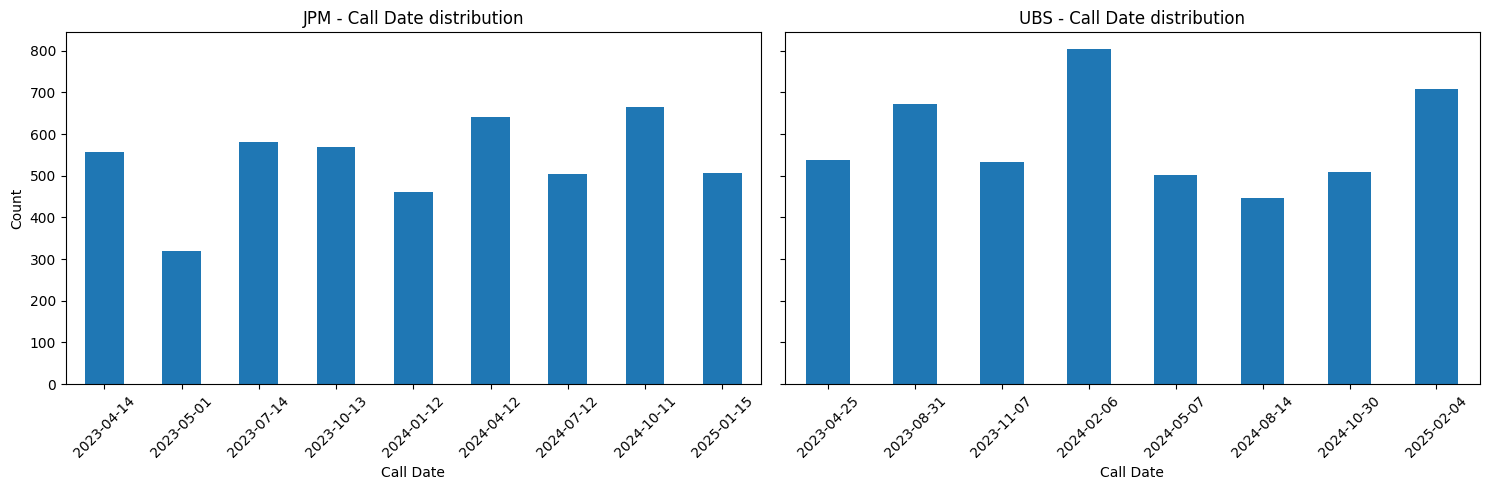

In [9]:
# Plot call_date distributions for each bank in side-by-side subplots
banks = data['bank'].dropna().unique()
fig, axes = plt.subplots(1, len(banks), figsize=(15, 5), sharey=True)

for ax, bank in zip(axes, banks):
    subset = data[data['bank'] == bank]
    counts = subset['call_date'].value_counts().sort_index()
    counts.plot(kind='bar', ax=ax)
    ax.set_title(f'{bank} - Call Date distribution')
    ax.set_xlabel('Call Date')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=45)

fig.tight_layout()
plt.show()

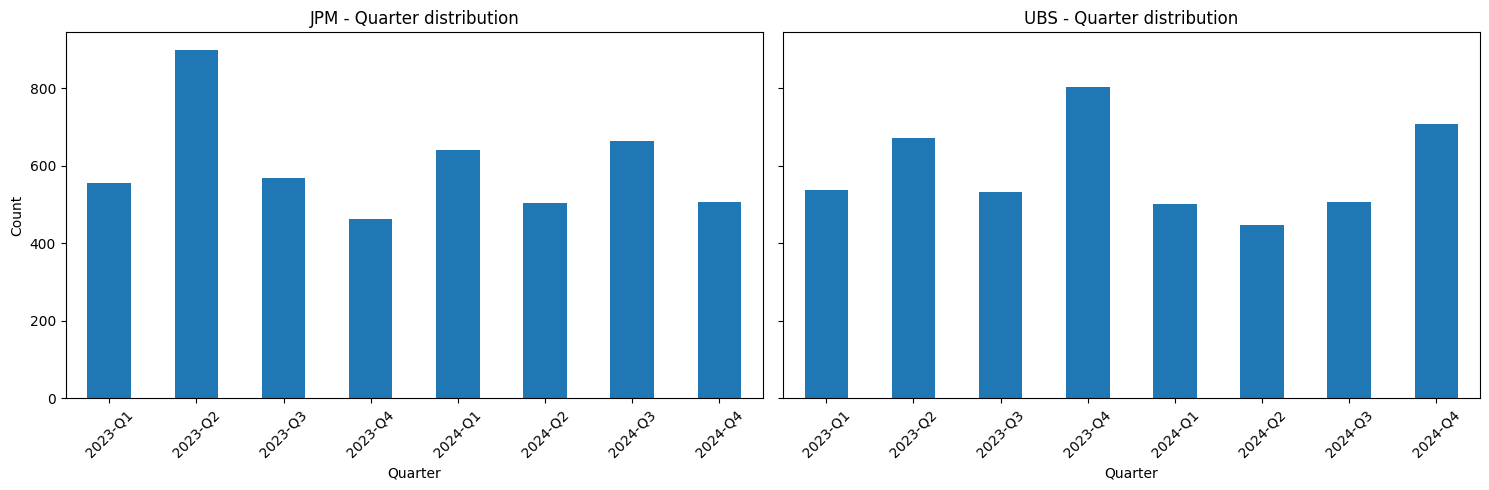

In [10]:
# Plot quarter distributions for each bank in side-by-side subplots
banks = data['bank'].dropna().unique()
fig, axes = plt.subplots(1, len(banks), figsize=(15, 5), sharey=True)

for ax, bank in zip(axes, banks):
    subset = data[data['bank'] == bank]
    counts = subset['quarter'].value_counts().sort_index()
    counts.plot(kind='bar', ax=ax)
    ax.set_title(f'{bank} - Quarter distribution')
    ax.set_xlabel('Quarter')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=45)

fig.tight_layout()
plt.show()

## Initial Word Clouds per bank
Not particularly useful as data has not been processed yet to remove greetings, names, stop words etc.

In [ ]:
# Install WordCloud
%pip install wordcloud
from wordcloud import WordCloud

In [ ]:
# Create word cloud from the text in the 'sentence' column for each bank name
for bank in data['bank'].unique():
    text = ' '.join(data.loc[data['bank'] == bank, 'sentence'])
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'Word Cloud for {bank}')
    plt.show()

## Top 20 words
Useful to see which words need to be removed for the pre-processing (stop words, greetings etc)

In [11]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
import re

# Download necessary NLTK data
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/rdrobinson/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     /Users/rdrobinson/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/rdrobinson/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/rdrobinson/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

### Preprocessing function

In [12]:
def preprocess_text(text):
    if not isinstance(text, str): # Handle non-string input, e.g., NaN
        return []
    # Convert to lowercase
    text = text.lower()
    # Remove punctuation and special characters
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Tokenize the text
    tokens = word_tokenize(text)

    # Remove stopwords and lemmatize
    stop_words = set(stopwords.words('english'))

    # Remove words that are not informative for topic modeling
    stop_words.update(['also', 'quarter', 'year', 'u', 'think', 'thats'])

    greeting_words = {
    "hello", "hi", "dear", "greetings",
    "thank", "thanks", "good", "morning",
    "afternoon", "evening",
    "ladies", "gentlemen", "sir", "madam",
    "yeah", "welcome"
}

    lemmatizer = WordNetLemmatizer()
    cleaned_tokens = [
        lemmatizer.lemmatize(word) for word in tokens
        if word not in stop_words and word.isalpha() and word not in greeting_words # Ensure only alphabetic words are kept and remove greeting words
    ]
    return [word for word in cleaned_tokens if word not in stop_words]

In [13]:
# Apply the preprocessing function
data['cleaned_text'] = data['sentence'].apply(preprocess_text)

# Display the first few rows
print(data[['sentence', 'cleaned_text']].head())

                                            sentence  \
0                Good morning, ladies and gentlemen.   
1  Welcome to JPMorgan Chase’s First Quarter 2023...   
2                       This call is being recorded.   
3  Your line will be muted for the duration of th...   
4           We will now go live to the presentation.   

                               cleaned_text  
0                                        []  
1  [jpmorgan, chase, first, earnings, call]  
2                          [call, recorded]  
3             [line, muted, duration, call]  
4                  [go, live, presentation]  


Top 20 most common words in conversation text:
[('billion', 1056), ('capital', 667), ('know', 611), ('market', 559), ('client', 550), ('net', 540), ('question', 507), ('revenue', 503), ('credit', 500), ('rate', 488), ('cost', 464), ('business', 458), ('well', 458), ('going', 434), ('deposit', 433), ('term', 427), ('would', 421), ('first', 391), ('asset', 391), ('higher', 379)]


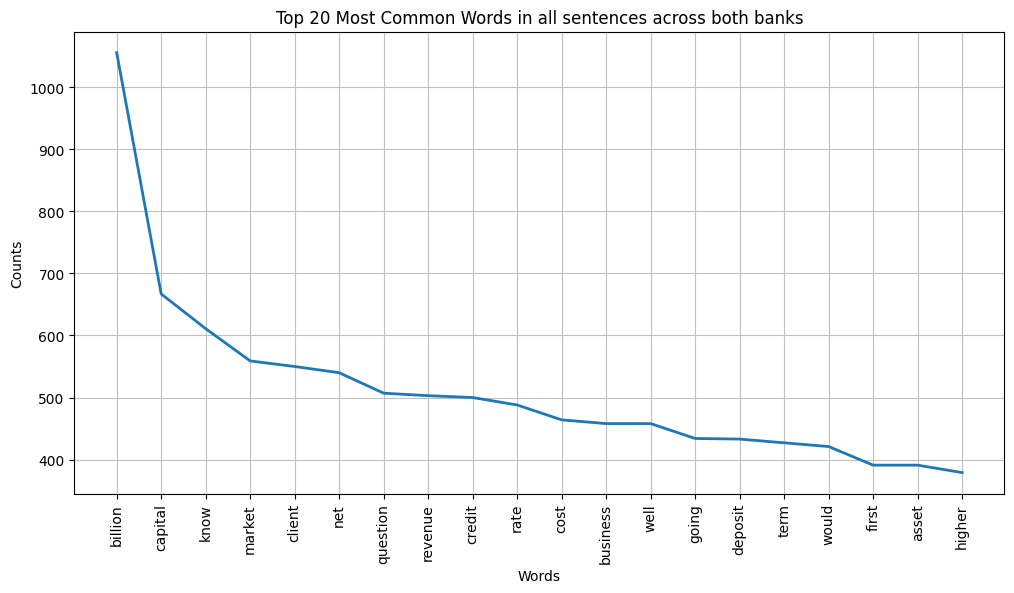

In [14]:
# Flatten the cleaned text into one list for the frequency distribution
data_all_words = [word for tokens in data['cleaned_text'] for word in tokens]

# Calculate frequency distribution
data_freq_dist = nltk.FreqDist(data_all_words)

# Display the top 20 most common words
print("Top 20 most common words in conversation text:")
print(data_freq_dist.most_common(20))

# Plotting the top 20 words
plt.figure(figsize=(12, 6))
data_freq_dist.plot(20, title='Top 20 Most Common Words in all sentences across both banks', cumulative=False)
plt.xlabel('Words')
plt.show()

Still has words like "would" & "going"

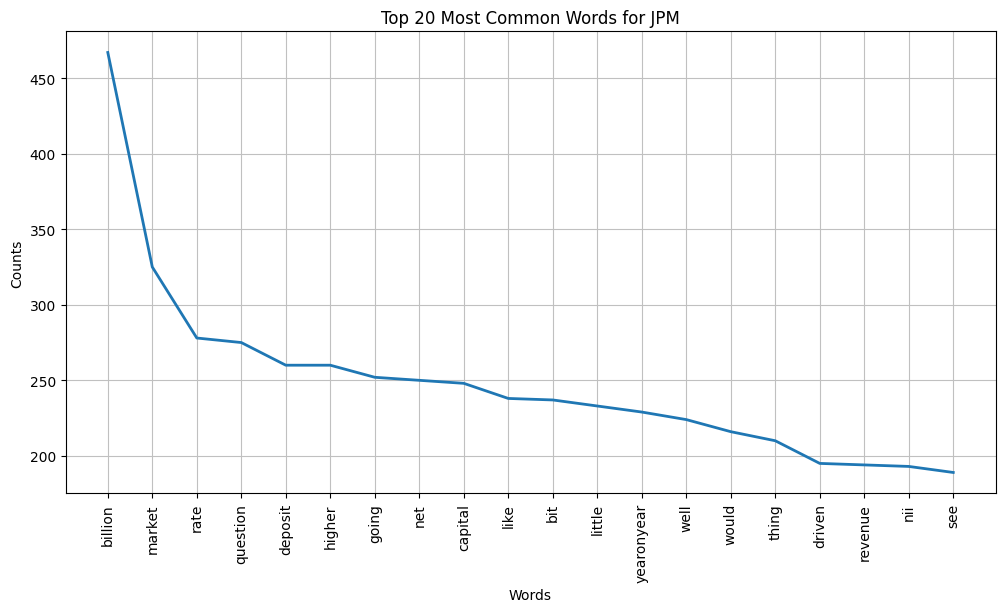

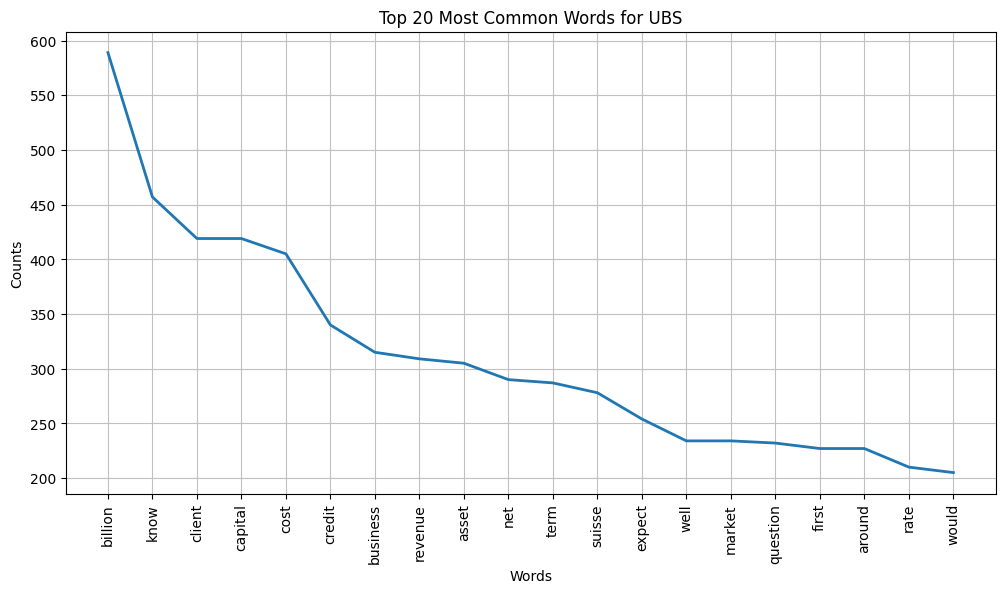

In [15]:
# Calculate frequency distribution for each bank
bank_freq_dists = {}
for bank in data['bank'].unique():
    bank_words = [word for tokens in data.loc[data['bank'] == bank, 'cleaned_text'] for word in tokens]
    bank_freq_dists[bank] = nltk.FreqDist(bank_words)
    plt.figure(figsize=(12, 6))
    bank_freq_dists[bank].plot(20, title=f'Top 20 Most Common Words for {bank}', cumulative=False)
    plt.xlabel('Words')
    plt.show()

UBS has credit and suisse in the top 20 - some of which are the bank "credit suisse" and some will be just the word "credit". Need to work out how to deal with this

Also still some words that may need checking - is "going" followed by "well" or "badly"?

# Bertopic

## Basic topic analysis - all sentences (both banks for initial test)
Issue with Hugging Face tokens using this model

In [ ]:
from bertopic import BERTopic

In [ ]:
# BERTopic expects an iterable of documents, where each document is a string.
documents = data["cleaned_text"].apply(lambda tokens: " ".join(tokens)).tolist()

In [ ]:
# Initialize the BERTopic model
model = BERTopic(language="english", calculate_probabilities=True,
                 verbose=True, min_topic_size = 10, nr_topics = 10)

# Fit the model on the combined negative reviews
topics, probs = model.fit_transform(documents)

# Get topic information
topic_info = model.get_topic_info()

print("Topic Modelling complete. Here are the key topics:")
print(topic_info.head(10))

In [ ]:
# Plot topics
print("\nTopic Visualization:")
# Exclude BERTopic's outlier topic (-1)
valid_topics = topic_info.loc[topic_info["Topic"] != -1, "Topic"].tolist()

if len(valid_topics) >= 2:
    try:
        try:
            topic_plot = model.visualize_topics(topics=valid_topics)
        except (TypeError, ValueError):
            # This can occur when the number of topics is too small
            # for the sparse eigensolver used by the topic map.
            print("Topic map unavailable; displaying topic frequencies instead.")
            topic_plot = model.visualize_barchart(
            top_n_topics=len(valid_topics),
            n_words=10
            )
    except ValueError:
        print("Topic map unavailable; displaying topic frequencies instead.")
        topic_plot = model.visualize_barchart(
            top_n_topics=len(valid_topics),
            n_words=10
        )
else:
    print("A topic map requires at least two non-outlier topics.")
    topic_plot = model.visualize_barchart(
        top_n_topics=len(valid_topics),
        n_words=10
    )
topic_plot.show()

In [ ]:
# Plot topic frequencies
freq_plot = model.visualize_barchart(
    top_n_topics=len(valid_topics),
    n_words=10
)
freq_plot.show()

We need to remove the names of people from this !!

Possible option:

pip install spacy
python -m spacy download en_core_web_sm

import spacy

nlp = spacy.load("en_core_web_sm")
text = "John Smith went to London to meet Dr. Jacob."

doc = nlp(text)

....#Rebuild text excluding PERSON entities
new_words = []
for token in doc:
  if token.ent_type_ != "PERSON":
    new_words.append(token.text_with_ws)
  else:
    new_words.append("[REDACTED]")

clean_text = "".join(new_words)
print(clean_text)

# Basic emotion analysis

## Both banks for initial test
Just average emotion scores across all sentances

/Users/rdrobinson/Cambridge/boe-financial-analysis/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 201/201 [00:00<00:00, 8688.60it/s]


Sentence emotion analysis:
[{'label': 'anger', 'score': 0.29154786467552185}, {'label': 'joy', 'score': 0.5934081673622131}, {'label': 'anger', 'score': 0.5362944006919861}, {'label': 'anger', 'score': 0.6360952854156494}, {'label': 'joy', 'score': 0.9826142191886902}, {'label': 'joy', 'score': 0.9436234831809998}, {'label': 'joy', 'score': 0.781797468662262}, {'label': 'joy', 'score': 0.958483874797821}, {'label': 'anger', 'score': 0.7296066880226135}, {'label': 'anger', 'score': 0.59098881483078}, {'label': 'joy', 'score': 0.9911655783653259}, {'label': 'anger', 'score': 0.3588503301143646}, {'label': 'sadness', 'score': 0.9164242148399353}, {'label': 'joy', 'score': 0.9773510694503784}, {'label': 'joy', 'score': 0.9935163259506226}, {'label': 'joy', 'score': 0.32183411717414856}, {'label': 'joy', 'score': 0.9511504769325256}, {'label': 'joy', 'score': 0.9754054546356201}, {'label': 'joy', 'score': 0.8080428242683411}, {'label': 'anger', 'score': 0.6347299218177795}, {'label': 'joy',

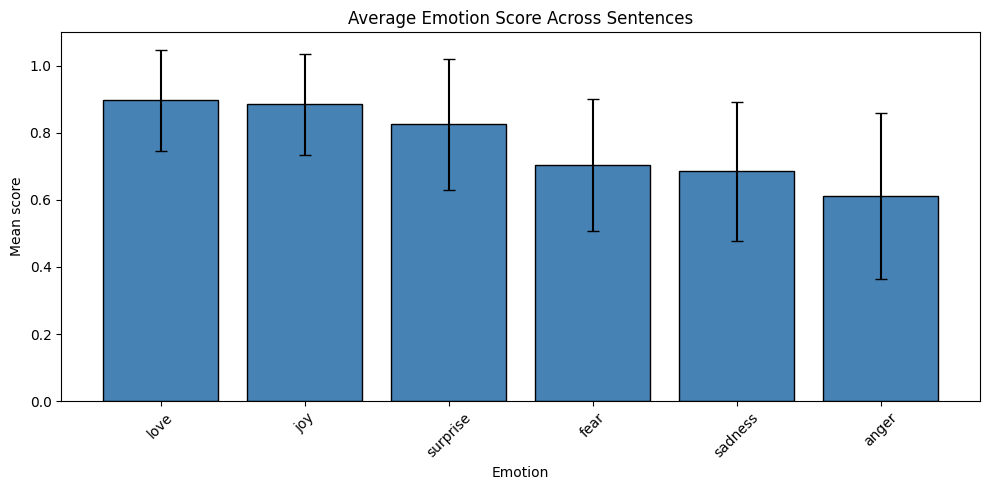

In [16]:
## Initial tests
# Conduct Bert Emotion analysis on cleaned sentences
from transformers import pipeline
emotion_analyzer = pipeline("text-classification", model="bhadresh-savani/bert-base-uncased-emotion")
documents = (
    data["cleaned_text"]
    .apply(lambda tokens: " ".join(tokens) if isinstance(tokens, list) else str(tokens))
    .tolist()
 )
basic_emotion = emotion_analyzer(documents, truncation=True)

print("Sentence emotion analysis:")
print(basic_emotion)

# Plot mean emotion scores with standard-deviation error bars
emotion_results = pd.DataFrame(basic_emotion)
emotion_summary = emotion_results.groupby("label")["score"].agg(["mean", "std"]).sort_values("mean", ascending=False)
emotion_summary["std"] = emotion_summary["std"].fillna(0)

plt.figure(figsize=(10, 5))
plt.bar(
    emotion_summary.index,
    emotion_summary["mean"],
    yerr=emotion_summary["std"],
    capsize=4,
    color="steelblue",
    edgecolor="black"
 )
plt.xlabel("Emotion")
plt.ylabel("Mean score")
plt.title("Average Emotion Score Across Sentences")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Note that the average score for all of the sentences combined is plotted. Previous versions just overlaid each set of results on top of the previous, hence the bar chart was simply the final sentence analysed. One advantage of this is that error bars can now be added


## USB emotions in 2023

### Separate out UBS in 2023

In [17]:
# Conduct BERT Emotion analysis on documents with bank = UBS and quarter = 2023-Q1
ubs_documents = (
    data.loc[
        (data["bank"].str.lower() == "ubs") & (data["quarter"] == "2023-Q1"),
        "cleaned_text"
    ]
    .apply(lambda tokens: " ".join(tokens) if isinstance(tokens, list) else str(tokens))
    .tolist()
 )

basic_emotion = emotion_analyzer(ubs_documents, truncation=True)

print("Sentence emotion analysis for UBS:")
print(basic_emotion)

# Store data with sentance number
ubs_emotion_results = pd.DataFrame(basic_emotion)
ubs_emotion_results["sentence_number"] = range(1, len(ubs_emotion_results) + 1)

ubs_emotion_summary = (
    ubs_emotion_results.groupby("label")["score"]
    .agg(["mean", "std"])
    .sort_values("mean", ascending=False)
 )
ubs_emotion_summary["std"] = ubs_emotion_summary["std"].fillna(0)

Sentence emotion analysis for UBS:
[{'label': 'anger', 'score': 0.7325093746185303}, {'label': 'joy', 'score': 0.995882511138916}, {'label': 'joy', 'score': 0.9909369349479675}, {'label': 'joy', 'score': 0.874218761920929}, {'label': 'joy', 'score': 0.9964756369590759}, {'label': 'joy', 'score': 0.7256629467010498}, {'label': 'joy', 'score': 0.9959501028060913}, {'label': 'anger', 'score': 0.944121778011322}, {'label': 'joy', 'score': 0.9956008195877075}, {'label': 'joy', 'score': 0.7882832884788513}, {'label': 'joy', 'score': 0.9466054439544678}, {'label': 'joy', 'score': 0.9725730419158936}, {'label': 'joy', 'score': 0.9945249557495117}, {'label': 'joy', 'score': 0.9914754629135132}, {'label': 'joy', 'score': 0.9820072054862976}, {'label': 'anger', 'score': 0.6292346119880676}, {'label': 'joy', 'score': 0.9380383491516113}, {'label': 'joy', 'score': 0.9949723482131958}, {'label': 'joy', 'score': 0.9880453944206238}, {'label': 'joy', 'score': 0.9004260897636414}, {'label': 'joy', 'sco

In [18]:
ubs_emotion_results.tail(5)


,label,score,sentence_number
534,joy,0.997370,535
535,joy,0.751915,536
536,joy,0.712608,537
537,joy,0.993899,538
538,anger,0.291548,539


I'm assuming that this is the "winning" emotion for each sentence, rather than a score of each emotion for each sentence

### All emotion scores
Each sentance scored separately

In [20]:
import seaborn as sns

emotions = ubs_emotion_results["label"].unique()
colors = sns.color_palette("Set2", n_colors=len(emotions))
emotion_colors = dict(zip(emotions, colors))

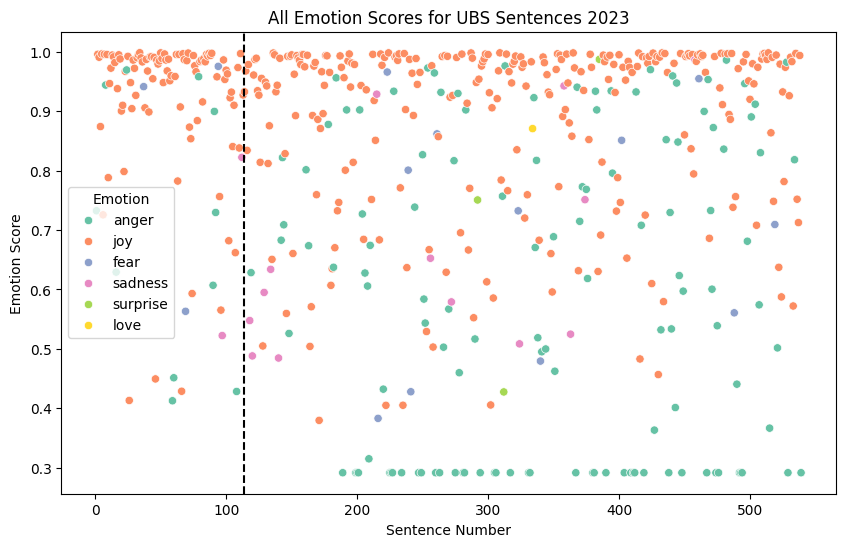

In [21]:
# Plot all emotion scores as a scatter plot from ubs_emotion_results



plt.figure(figsize=(10, 6))
sns.scatterplot(data=ubs_emotion_results, x="sentence_number", y="score", hue="label", palette=emotion_colors)
plt.title("All Emotion Scores for UBS Sentences 2023")
plt.xlabel("Sentence Number")
plt.ylabel("Emotion Score")
# Add vertical reference line at x=114
plt.axvline(x=114, color='black', linestyle='--')
plt.legend(title="Emotion")
plt.show()

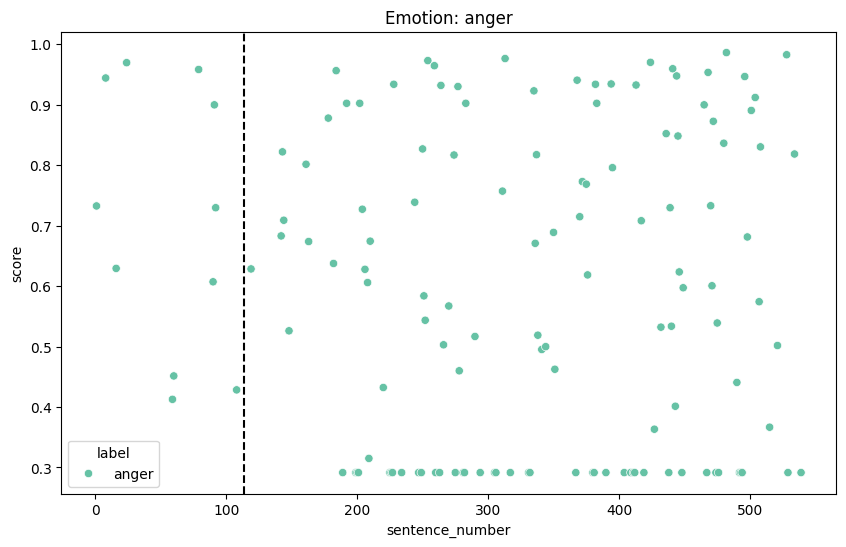

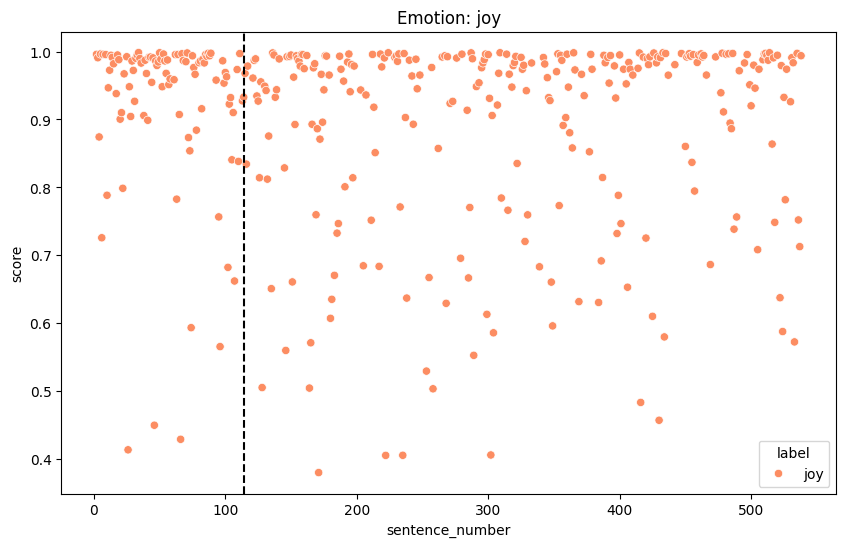

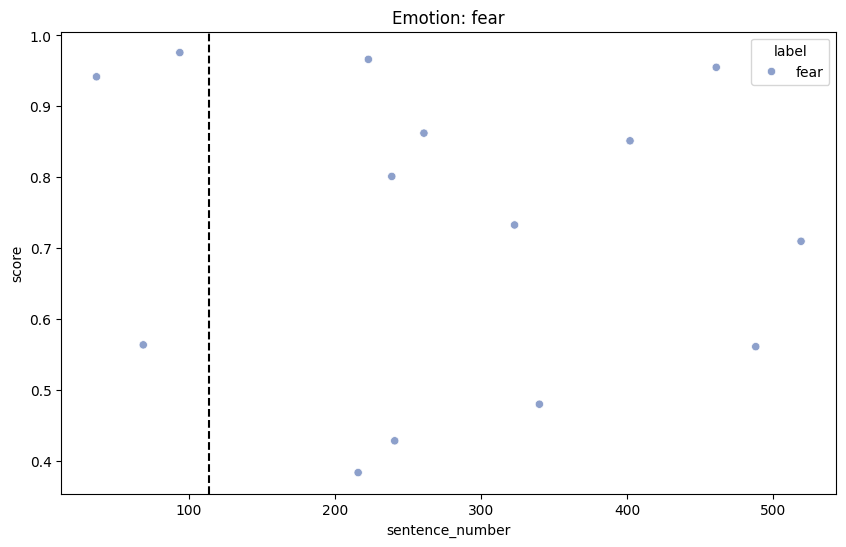

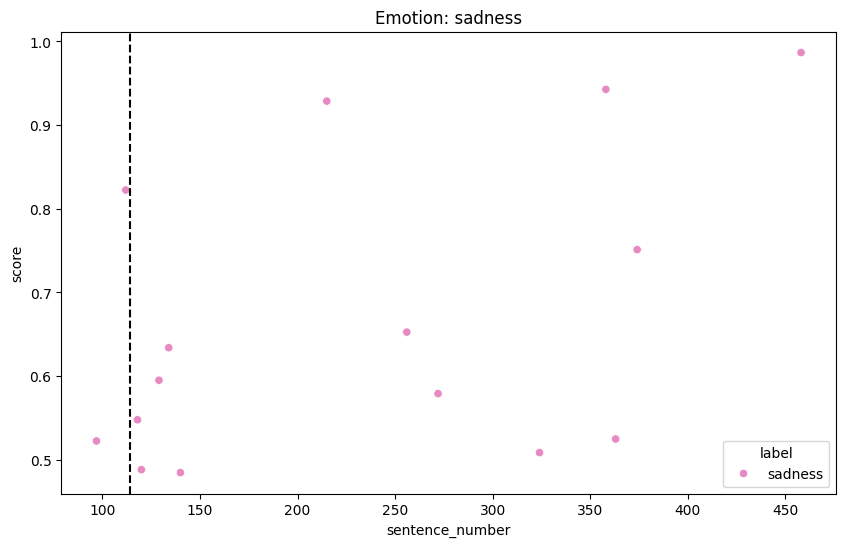

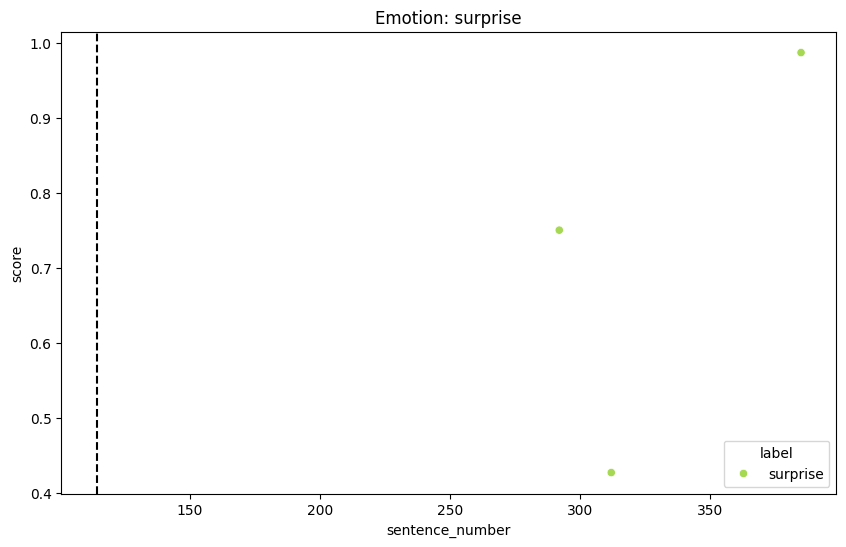

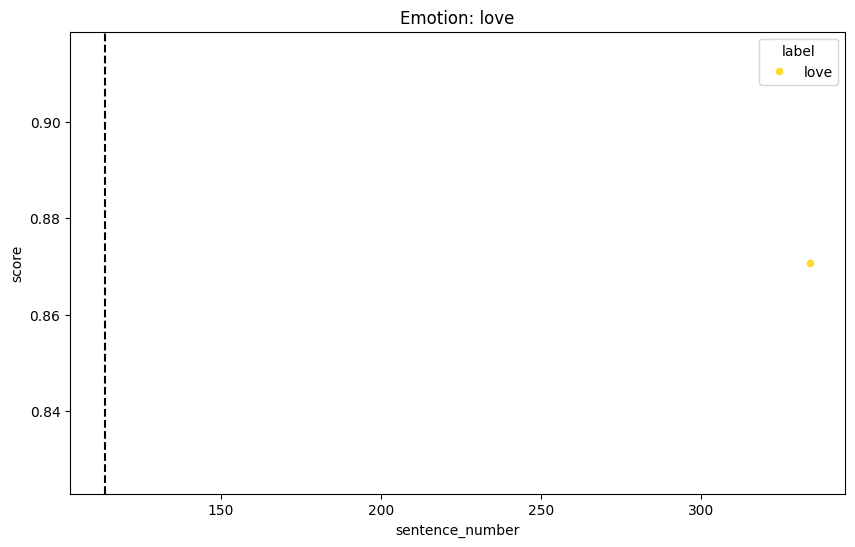

In [22]:
# Plot each emotion as a separate scatter plot with different colors for each emotion

emotions = ubs_emotion_results['label'].unique()
for emotion in emotions:
    subset = ubs_emotion_results[ubs_emotion_results['label'] == emotion]
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=subset, x="sentence_number", y="score", hue="label", palette=emotion_colors)
    plt.axvline(x=114, color='black', linestyle='--')
    plt.title(f"Emotion: {emotion}")
    plt.show()

The line between report and Q&A is potentially useful but will be different in each report so this may not be that useful

### Mean emotion scores
Calculating the mean & standard deviation of all sentences in a quarter

In [23]:
ubs_emotion_summary.head(5)

,mean,std
label,,
joy,0.897803,0.142099
love,0.870791,0.000000
fear,0.729130,0.211165
surprise,0.721857,0.281027
sadness,0.664571,0.176851


Start with 1 quarter and then build up

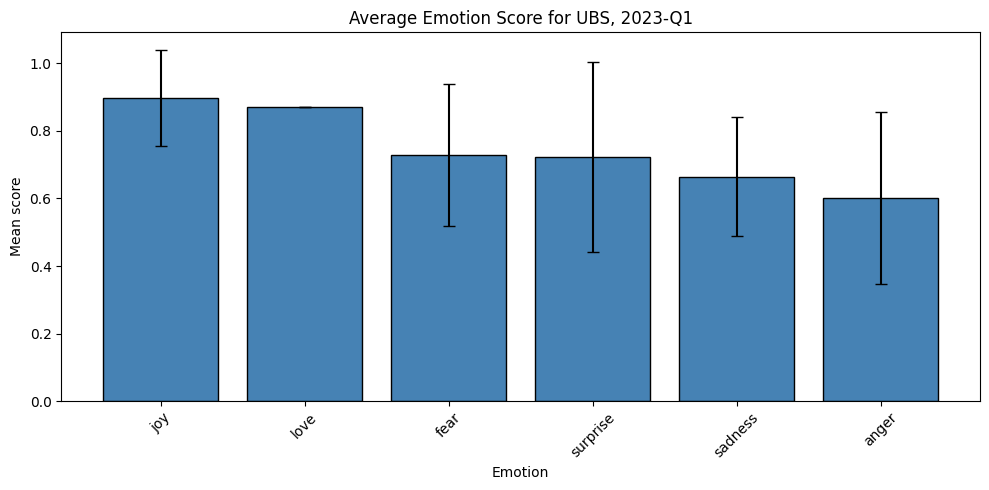

In [24]:
# Plot mean emotion scores with standard-deviation error bars for Q1

plt.figure(figsize=(10, 5))
plt.bar(
    ubs_emotion_summary.index,
    ubs_emotion_summary["mean"],
    yerr=ubs_emotion_summary["std"],
    capsize=4,
    color="steelblue",
    edgecolor="black"
 )
plt.xlabel("Emotion")
plt.ylabel("Mean score")
plt.title("Average Emotion Score for UBS, 2023-Q1")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Changing average emotions over time (UBS 2023)
The rise in "surprise in Q2 2023 !!

In [26]:
# Inspect the separately stored sentence-level results for every quarter
for quarter, results in ubs_emotion_results_by_quarter.items():
    print(f"{quarter}: {len(results)} sentences")
    display(results.head(10))

2023-Q1: 539 sentences


,label,score,sentence_number,quarter
0,anger,0.732509,1,2023-Q1
1,joy,0.995883,2,2023-Q1
2,joy,0.990937,3,2023-Q1
3,joy,0.874219,4,2023-Q1
4,joy,0.996476,5,2023-Q1
5,joy,0.725663,6,2023-Q1
6,joy,0.995950,7,2023-Q1
7,anger,0.944122,8,2023-Q1
8,joy,0.995601,9,2023-Q1
9,joy,0.788283,10,2023-Q1


2023-Q2: 672 sentences


,label,score,sentence_number,quarter
0,anger,0.732509,1,2023-Q2
1,joy,0.998515,2,2023-Q2
2,anger,0.707796,3,2023-Q2
3,joy,0.995678,4,2023-Q2
4,joy,0.397483,5,2023-Q2
5,joy,0.992901,6,2023-Q2
6,anger,0.653000,7,2023-Q2
7,joy,0.996618,8,2023-Q2
8,joy,0.942662,9,2023-Q2
9,joy,0.951823,10,2023-Q2


2023-Q3: 534 sentences


,label,score,sentence_number,quarter
0,anger,0.732509,1,2023-Q3
1,joy,0.886214,2,2023-Q3
2,sadness,0.994499,3,2023-Q3
3,sadness,0.953433,4,2023-Q3
4,joy,0.773405,5,2023-Q3
5,fear,0.977969,6,2023-Q3
6,joy,0.663334,7,2023-Q3
7,joy,0.996192,8,2023-Q3
8,joy,0.988781,9,2023-Q3
9,joy,0.996587,10,2023-Q3


2023-Q4: 804 sentences


,label,score,sentence_number,quarter
0,joy,0.909025,1,2023-Q4
1,anger,0.787508,2,2023-Q4
2,fear,0.582319,3,2023-Q4
3,joy,0.995223,4,2023-Q4
4,joy,0.950914,5,2023-Q4
5,joy,0.968579,6,2023-Q4
6,sadness,0.976090,7,2023-Q4
7,anger,0.508193,8,2023-Q4
8,joy,0.997729,9,2023-Q4
9,joy,0.997017,10,2023-Q4


In [27]:
# Combine all quarterly emotion summaries into one DataFrame.
average_emotion_counts_by_quarter = pd.concat(
    [
        summary.assign(Quarter=quarter)
        for quarter, summary in ubs_emotion_summaries.items()
    ]
)

average_emotion_counts_by_quarter = (
    average_emotion_counts_by_quarter
    .reset_index()
    .rename(columns={
        "label": "emotion",
        "mean": "mean",
        "std": "standard deviation"
    })
)

# Convert each quarter to its ending timestamp.
average_emotion_counts_by_quarter["Time"] = pd.PeriodIndex(
    average_emotion_counts_by_quarter["Quarter"],
    freq="Q"
).to_timestamp(how="end")

average_emotion_counts_by_quarter

,emotion,mean,standard deviation,Quarter,Time
0,joy,0.897803,0.142099,2023-Q1,2023-03-31 23:59:59.999999999
1,love,0.870791,0.000000,2023-Q1,2023-03-31 23:59:59.999999999
2,fear,0.729130,0.211165,2023-Q1,2023-03-31 23:59:59.999999999
3,surprise,0.721857,0.281027,2023-Q1,2023-03-31 23:59:59.999999999
4,sadness,0.664571,0.176851,2023-Q1,2023-03-31 23:59:59.999999999
5,anger,0.600520,0.254267,2023-Q1,2023-03-31 23:59:59.999999999
6,surprise,0.988232,0.001522,2023-Q2,2023-06-30 23:59:59.999999999
7,joy,0.895661,0.146591,2023-Q2,2023-06-30 23:59:59.999999999
8,fear,0.726857,0.192830,2023-Q2,2023-06-30 23:59:59.999999999
9,sadness,0.647578,0.178846,2023-Q2,2023-06-30 23:59:59.999999999


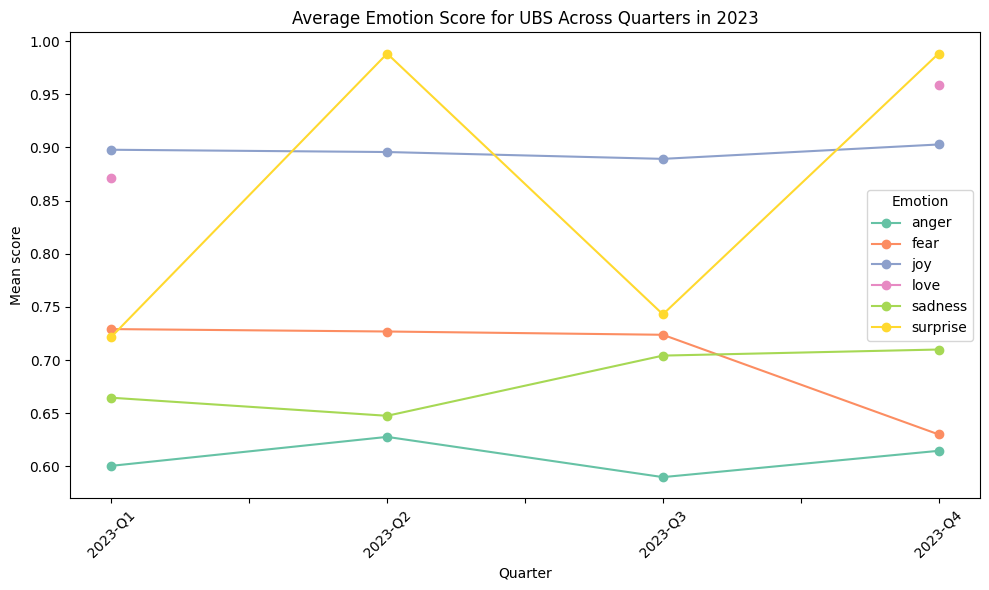

In [28]:
summary_df = pd.concat(
    [
        summary.reset_index().rename(
            columns={"label": "emotion", "mean": "mean", "std": "std"}
        ).assign(quarter=quarter)
        for quarter, summary in ubs_emotion_summaries.items()
    ],
    ignore_index=True,
)

pivot = summary_df.pivot(
    index="quarter",
    columns="emotion",
    values="mean",
).reindex(["2023-Q1", "2023-Q2", "2023-Q3", "2023-Q4"])

# Preserve the same colour for each emotion.
emotion_colors = dict(
    zip(
        pivot.columns,
        sns.color_palette("Set2", n_colors=len(pivot.columns)),
    )
)

ax = pivot.plot(
    kind="line",
    marker="o",
    figsize=(10, 6),
    color=[emotion_colors[emotion] for emotion in pivot.columns],
)

plt.xlabel("Quarter")
plt.ylabel("Mean score")
plt.title("Average Emotion Score for UBS Across Quarters in 2023")
plt.legend(title="Emotion")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Notes from the internet to possibly explain the rise in "Surprise" in Q2 2023**

Negotiations surrounding an acquisition began on 15 March. Swiss authorities asserted that a deal had to be done before 20 March, the following Monday, to help prevent the panic from spreading around the world. Issues discussed during the short negotiation period included UBS not wanting Credit Suisse's unprofitable investment bank, antitrust issues from combining Switzerland's two largest banks, the size of a government backstop, and whether to bypass shareholder votes
Losses in investment banking arm


(https://en.wikipedia.org/wiki/Acquisition_of_Credit_Suisse_by_UBS)
Credit Suisse chairman Axel Lehmann recalled at the April 2023 shareholders' meeting, after the collapse of his company, that "After the financial crisis we were named the 'Best Bank Globally'. The years since ... that is the bitter reality".[17] Between 2008 and 2023, Credit Suisse's investment banking arm underperformed, dragging down the business's profitability and causing significant losses.[10] The bank suffered from a series of scandals and mismanagement, including losses in its investment arm associated with the collapses of Archegos Capital and Greensill Capital in 2021.[18] Social media rumors about the bank's demise in October 2022 aided CHF 111 billion in outflows from its wealth management business in the last three months of the year.[15][19] The bank's internal control over financial reporting was flagged by its auditor, PwC, for the period 2020 to 2022.[20]